Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz 

In [88]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

import os
os.listdir()
print(os.getcwd())
os.chdir('/Users/zoehendershot/DS-3021/data')

movie_metadata = pd.read_csv("movie_metadata.csv")
movie_titles = movie_metadata[['movie_title']]



/Users/zoehendershot/DS-3021/data


#2 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [74]:
cat_vars = ['color', 'language', 'country', 'content_rating']
for col in cat_vars:
    movie_metadata[col] = movie_metadata[col].astype('category')
print(movie_metadata.dtypes)




color                        category
director_name                  object
num_critic_for_reviews        float64
duration                      float64
director_facebook_likes       float64
actor_3_facebook_likes        float64
actor_2_name                   object
actor_1_facebook_likes        float64
gross                         float64
genres                         object
actor_1_name                   object
movie_title                    object
num_voted_users                 int64
cast_total_facebook_likes       int64
actor_3_name                   object
facenumber_in_poster          float64
plot_keywords                  object
movie_imdb_link                object
num_user_for_reviews          float64
language                     category
country                      category
content_rating               category
budget                        float64
title_year                    float64
actor_2_facebook_likes        float64
imdb_score                    float64
aspect_ratio

In [75]:
#checking value counts for categorical variables to collapse
for col in cat_vars:
    if col in movie_metadata.columns:
        print(f"\n{col} value counts:")
        print(movie_metadata[col].value_counts())



color value counts:
Color               4815
 Black and White     209
Name: color, dtype: int64

language value counts:
English       4704
French          73
Spanish         40
Hindi           28
Mandarin        26
German          19
Japanese        18
Italian         11
Cantonese       11
Russian         11
Korean           8
Portuguese       8
Danish           5
Hebrew           5
Swedish          5
Arabic           5
Dutch            4
Polish           4
Persian          4
Norwegian        4
Chinese          3
Thai             3
Romanian         2
None             2
Aboriginal       2
Zulu             2
Dari             2
Indonesian       2
Icelandic        2
Czech            1
Vietnamese       1
Urdu             1
Aramaic          1
Telugu           1
Tamil            1
Bosnian          1
Swahili          1
Kazakh           1
Slovenian        1
Maya             1
Dzongkha         1
Filipino         1
Greek            1
Hungarian        1
Panjabi          1
Mongolian        1
Kanna

In [76]:
# Combine Not Rated and Unrated categories
movie_metadata['content_rating'] = movie_metadata['content_rating'].replace({'Unrated': 'Not Rated',})

# pick top 4 most frequent ratings and map all the other less-common ratings to an other category
main_ratings = ['R', 'PG-13', 'PG', 'Not Rated']
movie_metadata['content_rating'] = movie_metadata['content_rating'].apply(lambda x: x if x in main_ratings else 'Other')

print(movie_metadata['content_rating'].value_counts())


# same collapsing method for countries
main_countries = ['USA', 'UK', 'France', 'Canada']
movie_metadata['country'] = movie_metadata['country'].apply(lambda x: x if x in main_countries else 'Other')

print(movie_metadata['country'].value_counts())

#same collapsing method for languages
main_languages = ['English', 'French', 'Spanish']
movie_metadata['language'] = movie_metadata['language'].apply(lambda x: x if x in main_languages else 'Other')

print(movie_metadata['language'].value_counts())

drop_columns = ["actor_1_name", "actor_3_name", "movie_title", "movie_imdb_link", "director_name", "director_facebook_likes", "actor_1_facebook_likes", "actor_2_facebook_likes", "actor_3_facebook_likes", "actor_2_name", "aspect_ratio", "facenumber_in_poster", "num_critic_for_reviews", "num_user_for_reviews", "movie_facebook_likes", "cast_total_facebook_likes",]
movie_metadata = movie_metadata.drop(columns=drop_columns, errors="ignore")

movie_metadata["plot_keywords"] = movie_metadata["plot_keywords"].apply(
    lambda x: x.split("|")[0] if isinstance(x, str) and "|" in x else x
    )
movie_metadata["plot_keywords"] = movie_metadata["plot_keywords"].astype('category')
from sklearn.preprocessing import LabelEncoder

movie_metadata["plot_keywords"] = LabelEncoder().fit_transform(movie_metadata["plot_keywords"])

movie_metadata["genres"] = movie_metadata["genres"].apply(
    lambda x: x.split("|")[0] if isinstance(x, str) and "|" in x else x
    )
movie_metadata["genres"] = movie_metadata["genres"].astype('category')
from sklearn.preprocessing import LabelEncoder

movie_metadata["genres"] = LabelEncoder().fit_transform(movie_metadata["genres"])

movie_metadata["language"] = movie_metadata["language"].astype('category')
from sklearn.preprocessing import LabelEncoder

movie_metadata["language"] = LabelEncoder().fit_transform(movie_metadata["language"])

movie_metadata["country"] = movie_metadata["country"].astype('category')
from sklearn.preprocessing import LabelEncoder

movie_metadata["country"] = LabelEncoder().fit_transform(movie_metadata["country"])

movie_metadata["content_rating"] = movie_metadata["content_rating"].astype('category')
from sklearn.preprocessing import LabelEncoder

movie_metadata["content_rating"] = LabelEncoder().fit_transform(movie_metadata["content_rating"])




R            2118
PG-13        1461
PG            701
Other         282
Not Rated     178
Name: content_rating, dtype: int64
USA       3807
Other      503
UK         448
France     154
Canada     126
Name: country, dtype: int64
English    4704
Other       214
French       73
Spanish      40
Name: language, dtype: int64


#3 Check for missing variables and correct as needed. Once you've completed the cleaning again create a function that will do this for you in the future. In the submission, include only the function and the function call.

In [77]:
# Check for missing values in each column
missing_values = movie_metadata.isna().sum()
#print(missing_values[missing_values > 0])  # Display only columns with missing values

for col in missing_values.index:
    if movie_metadata[col].dtype == 'float64' or movie_metadata[col].dtype == 'int64':
        # Impute numerical columns with median (robust to outliers)
        movie_metadata[col].fillna(movie_metadata[col].median(), inplace=True)

    elif movie_metadata[col].dtype.name == 'category':
        # Impute categorical columns with mode (most common category)
        movie_metadata[col].fillna(movie_metadata[col].mode()[0], inplace=True)

    elif movie_metadata[col].dtype == 'object':
        # For plain text columns, also use mode or a placeholder like 'Unknown'
        movie_metadata[col].fillna('Unknown', inplace=True)

# Sanity check after filling
print("Remaining missing values:")
print(movie_metadata.isna().sum()[movie_metadata.isna().sum() > 0])



Remaining missing values:
Series([], dtype: int64)


In [67]:
def clean_data(df, category_threshold=100, rare_level_threshold=0.05):
    df = df.copy()

    # Convert object columns with less than 100 unique values to category
    for col in df.select_dtypes(include='object').columns:
        if df[col].nunique() <= category_threshold:
            df[col] = df[col].astype('category')

    # Collapse rare levels (less than 5% of the data) in categorical columns
    for col in df.select_dtypes(include='category').columns:
        value_counts = df[col].value_counts(normalize=True)
        rare_levels = value_counts[value_counts < rare_level_threshold].index
        df[col] = df[col].apply(lambda x: 'Other' if x in rare_levels else x).astype('category')

    # Handle missing values
    for col in df.columns:
        if df[col].isna().sum() == 0:
            continue
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        elif df[col].dtype.name == 'category':
            df[col].fillna(df[col].mode()[0], inplace=True)
        elif df[col].dtype in ['object', 'string']:
            df[col].fillna('Unknown', inplace=True)

    return df


#4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

#5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [78]:
movie_metadata['high_rating'] = (movie_metadata['imdb_score'] >= 7).astype(int)
print(movie_metadata['high_rating'].dtype)
print(movie_metadata['high_rating'].value_counts())
movie_metadata['color'] = movie_metadata['color'].apply(lambda x: 1 if x == 'Color' else 0)
print(movie_metadata['color'].value_counts())

int64
0    3265
1    1778
Name: high_rating, dtype: int64
1    4834
0     209
Name: color, dtype: int64


In [79]:
#check prevalence
(1778/(1778+3265))

0.3525679159230617

#6 Split your data into test, tune, and train. (80/10/10)

In [80]:
#split independent and dependent variables 
X = movie_metadata.drop(columns=['imdb_score', 'high_rating'])  # drop both targets
y = movie_metadata['high_rating']  # classifier variable


In [81]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test, y_test, train_size = 0.50, stratify= y_test, random_state=49)
print(f"Train: {X_train.shape}")
print(f"Tune:  {X_tune.shape}")
print(f"Test:  {X_test.shape}")



Train: (3530, 11)
Tune:  (756, 11)
Test:  (757, 11)


#7 Create the kfold object for cross validation.

In [82]:
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

#8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter (grid search)

In [83]:
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}

#9 Build the classifier object 

In [84]:
cl= DecisionTreeClassifier(random_state=1000)

#10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [85]:
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')
model = search.fit(X_train, y_train)

#11 Fit the model to the training data.

In [18]:
cl.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1000)

#12 What is the best depth value?

In [19]:
best = model.best_estimator_
print(best)

DecisionTreeClassifier(max_depth=6, random_state=1000)


#13 Print out the model

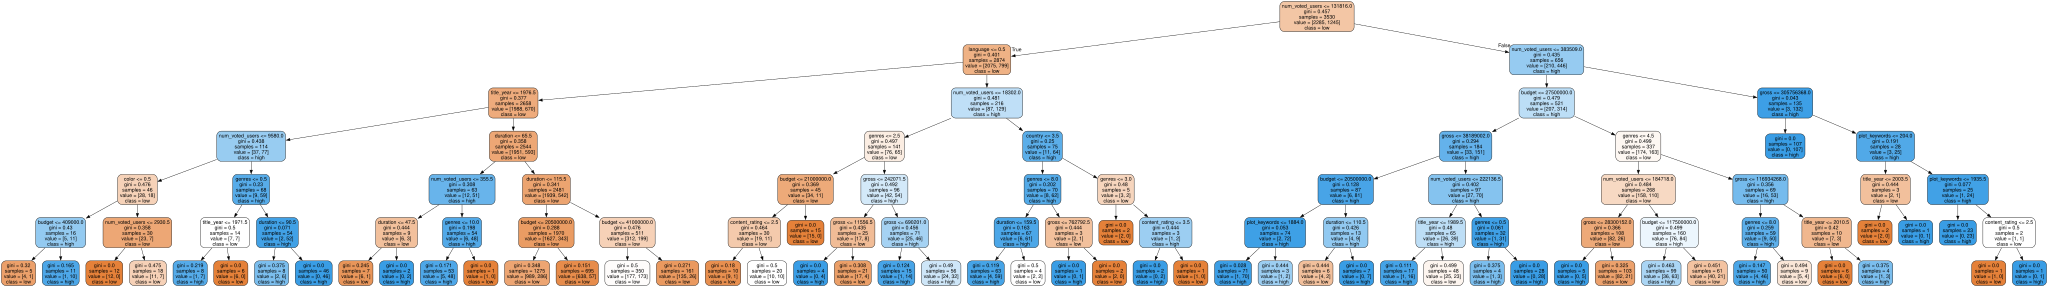

In [34]:
import graphviz

# Plotting the decision tree for the best estimator 
dot_data = export_graphviz(best, out_file=None,
               feature_names=X.columns,  # feature names from dataset
               filled=True, 
               rounded=True, 
               class_names=['low', 'high'])  # classification labels 
               
graph = graphviz.Source(dot_data)
graph

#14 View the results, comment on how the model performed using the metrics you selected

In [35]:
print(model.cv_results_)

{'mean_fit_time': array([0.00615095, 0.00912121, 0.01170596, 0.01553243, 0.01787915,
       0.02018834, 0.02569985, 0.03286608, 0.03505709, 0.03363911,
       0.03344236]), 'std_fit_time': array([0.00257189, 0.00303239, 0.00282176, 0.00382797, 0.00452674,
       0.00416681, 0.01686552, 0.01419019, 0.01152372, 0.00915761,
       0.00576751]), 'mean_score_time': array([0.00750883, 0.00912055, 0.0082685 , 0.00921454, 0.00820051,
       0.00852664, 0.00944016, 0.01264414, 0.01238314, 0.00924447,
       0.00890687]), 'std_score_time': array([0.00243235, 0.00299235, 0.00211434, 0.00354122, 0.00276806,
       0.00297981, 0.00504041, 0.01091651, 0.01038099, 0.00353939,
       0.00251454]), 'param_max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value='?',
            dtype=object), 'params': [{'max_depth': 1}, {'max_depth': 2}, {'max_depth': 3}, {'ma

In [36]:
print(model.cv_results_.keys())

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_max_depth', 'params', 'split0_test_roc_auc', 'split1_test_roc_auc', 'split2_test_roc_auc', 'split3_test_roc_auc', 'split4_test_roc_auc', 'split5_test_roc_auc', 'split6_test_roc_auc', 'split7_test_roc_auc', 'split8_test_roc_auc', 'split9_test_roc_auc', 'split10_test_roc_auc', 'split11_test_roc_auc', 'split12_test_roc_auc', 'split13_test_roc_auc', 'split14_test_roc_auc', 'split15_test_roc_auc', 'split16_test_roc_auc', 'split17_test_roc_auc', 'split18_test_roc_auc', 'split19_test_roc_auc', 'split20_test_roc_auc', 'split21_test_roc_auc', 'split22_test_roc_auc', 'split23_test_roc_auc', 'split24_test_roc_auc', 'split25_test_roc_auc', 'split26_test_roc_auc', 'split27_test_roc_auc', 'split28_test_roc_auc', 'split29_test_roc_auc', 'split30_test_roc_auc', 'split31_test_roc_auc', 'split32_test_roc_auc', 'split33_test_roc_auc', 'split34_test_roc_auc', 'split35_test_roc_auc', 'split36_test_roc_auc', 'split37_tes

In [37]:
#Scores: 

auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.619225,0.320639,0.619225,0.020605,0.052963,0.020605
2,0.655556,0.364175,0.630664,0.023604,0.078190,0.025929
3,0.693561,0.391841,0.650893,0.030390,0.077198,0.028371
4,0.720130,0.462337,0.676726,0.029954,0.069192,0.026419
5,0.751037,0.465920,0.685831,0.024488,0.065290,0.024242
6,0.773793,0.521791,0.703877,0.026091,0.065638,0.025384
7,0.770849,0.534801,0.711606,0.028041,0.063348,0.026572
8,0.764337,0.555175,0.717586,0.026468,0.054306,0.024558
9,0.759421,0.561618,0.721899,0.030677,0.039633,0.021156
10,0.747331,0.580271,0.724836,0.028932,0.038144,0.022214


The decision tree model had its highest AUC of 0.7738 at depth 6. Recall and balanced accuracy improved with tree depth, however, performance gains did not improve significantly after depth 6, indicating that deeper trees may not generalize better. Depth 6 offers the best balance between accuracy, recall, without running the risk of overfitting. 

#15 Which variables appear to be contributing the most (variable importance) 

In [38]:
#Variable importance for the best estimator, how much weight does each feature have in determining the classification?
varimp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(varimp)

                 importance
num_voted_users    0.417519
duration           0.144990
budget             0.138408
title_year         0.094481
language           0.078425
genres             0.055166
gross              0.046981
content_rating     0.007360
color              0.007093
plot_keywords      0.005949
country            0.003628


#16 Use the predict method on the tune data and print out the results.

In [41]:
# Use the best estimator from GridSearchCV to make predictions on the tune set
tune_predictions = best.predict(X_tune)

# Print the predictions
print(tune_predictions)


[0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 0 1 0 0
 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 1 0 0 1 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0
 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
 0 1 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1
 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 1 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0
 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1
 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 1 0 0 0
 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 

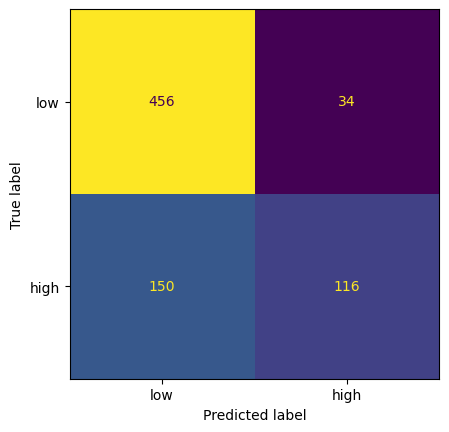

In [39]:
#Confusion Matrix time! Passing our tuning data into our best model, let's see how we do ...
print(ConfusionMatrixDisplay.from_estimator(best,X_tune,y_tune, display_labels = ['low','high'], colorbar=False))

#17 How does the model perform on the tune data?

In [43]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
tune_preds = best.predict(X_tune)
tune_probs = best.predict_proba(X_tune)[:, 1]  # for ROC AUC

# Accuracy
acc = accuracy_score(y_tune, tune_preds)
print(f"Accuracy: {acc:.4f}")

# ROC AUC
auc = roc_auc_score(y_tune, tune_probs)
print(f"ROC AUC: {auc:.4f}")

# Full classification report
print("\nClassification Report:")
print(classification_report(y_tune, tune_preds, target_names=['low', 'high']))

Accuracy: 0.7566
ROC AUC: 0.7880

Classification Report:
              precision    recall  f1-score   support

         low       0.75      0.93      0.83       490
        high       0.77      0.44      0.56       266

    accuracy                           0.76       756
   macro avg       0.76      0.68      0.69       756
weighted avg       0.76      0.76      0.74       756



#18 Print out the confusion matrix for the tune data, what does it tell you about the model?

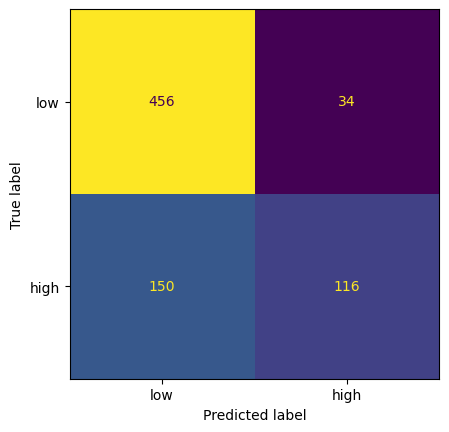

In [40]:
#Confusion Matrix time! Passing our tuning data into our best model, let's see how we do ...
print(ConfusionMatrixDisplay.from_estimator(best,X_tune,y_tune, display_labels = ['low','high'], colorbar=False))

#19 What are the top 3 movies based on the tune set? Which variables are most important in predicting the top 3 movies?

In [44]:
X_tune["predicted_rating"] = tune_preds
top_movies = X_tune.sort_values("predicted_rating", ascending=False).head(3)
print("Top 3 Movies:\n", top_movies)

Top 3 Movies:
      color  duration        gross  genres  num_voted_users  plot_keywords  \
3375     1     142.0   22800000.0       0            59941            725   
274      1     115.0  144795350.0       0           387632           1809   
299      1     103.0   85017401.0       0           246803           1042   

      language  country  content_rating       budget  title_year  \
3375         0        3               1    7000000.0      1969.0   
274          0        4               3  120000000.0      2004.0   
299          0        4               4   92000000.0      2012.0   

      predicted_rating  
3375                 1  
274                  1  
299                  1  


In [86]:
# Add predictions and true imdb scores to a new DataFrame
tune_results = X_tune.copy()
tune_results['predicted_high_rating'] = best.predict(X_tune)
tune_results['imdb_score'] = y_tune  # assuming y_tune holds actual imdb scores

# Get only those predicted as high
top_preds = tune_results[tune_results['predicted_high_rating'] == 1]

# Get top 3 based on imdb_score
top_3 = top_preds.sort_values(by='imdb_score', ascending=False).head(3)

print("Top 3 movies (rows):")
print(top_3)


Top 3 movies (rows):
     color  duration        gross  genres  num_voted_users  plot_keywords  \
2857     1     126.0   25592632.0      13           220475           1338   
3585     1     139.0  102300000.0       4           107408            511   
2163     1     112.0  137387272.0      13           300110            569   

      language  country  content_rating      budget  title_year  \
2857         0        4               4  18000000.0      2007.0   
3585         0        4               1   6000000.0      1964.0   
2163         0        4               4  20000000.0      2013.0   

      predicted_high_rating  imdb_score  
2857                      1           1  
3585                      1           1  
2163                      1           1  


In [89]:
top_3_indices = top_3.index
print(movie_titles.loc[top_3_indices, 'movie_title'])


2857         The Mist 
3585     Mary Poppins 
2163    The Conjuring 
Name: movie_title, dtype: object


#20 Use a different hyperparameter for the grid search function and go through the process above again using the tune set.

#21 Did the model improve with the new hyperparameter search?

#22 Using the better model, predict the test data and print out the results.

#23 Summarize what you learned along the way and make recommendations to your boss on how this could be used moving forward, being careful not to over promise.